In [1]:
 Анализ продукта: E-commerce воронка продаж

 Цель проекта

Проанализировать поведение пользователей в интернет-магазине и определить:

- где пользователи теряются в воронке продаж
- какие каналы привлекают самых ценных клиентов
- какие факторы влияют на покупку
- какие точки роста есть у продукта

 Описание данных

Источник: Direct-to-Consumer E-commerce Funnel Dataset

Датасет содержит сгенерированную информацию о пользовательских сессиях,
источниках привлечения, устройствах и покупательском поведении.

IndentationError: unexpected indent (653344390.py, line 3)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yashch05/direct-to-consumer-e-commerce-funnel-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\yashch05\direct-to-consumer-e-commerce-funnel-dataset\versions\1


In [ ]:
1. Импорт библиотек

Подключаем необходимые библиотеки для:

- обработки данных
- анализа
- визуализации

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
2. Загрузка данных

Загружаем датасет и изучаем его структуру.

In [5]:
df=pd.read_csv("C:/Users/Admin/.cache/kagglehub/datasets/yashch05/direct-to-consumer-e-commerce-funnel-dataset/versions/1/d2c_marketing_funnel_data.csv")

In [6]:
df.head()

,user_id,session_id,date,month,channel,campaign_type,device,user_type,region,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed,discount_applied,order_value,revenue
0,221958,1,8/16/2025,2025-08,Organic,New Launch,Mobile,New,Metro,Yes,No,No,No,No,No,499.00,0.000
1,771155,2,12/16/2025,2025-12,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,Yes,No,No,No,499.00,0.000
2,231932,3,7/17/2025,2025-07,Organic,Influencer,Mobile,New,Non-Metro,Yes,Yes,No,No,No,No,499.00,0.000
3,465838,4,7/4/2025,2025-07,Paid Ads,Discount,Mobile,Returning,Metro,Yes,Yes,Yes,Yes,Yes,Yes,2000.95,1800.855
4,359178,5,8/10/2025,2025-08,Paid Ads,Influencer,Mobile,Returning,Non-Metro,Yes,No,No,No,No,No,499.00,0.000


In [ ]:
3. Проверка качества данных

Проверяем:

- размер датасета
- типы данных
- пропущенные значения
- дубликаты

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             120000 non-null  int64  
 1   session_id          120000 non-null  int64  
 2   date                120000 non-null  str    
 3   month               120000 non-null  str    
 4   channel             120000 non-null  str    
 5   campaign_type       120000 non-null  str    
 6   device              120000 non-null  str    
 7   user_type           120000 non-null  str    
 8   region              120000 non-null  str    
 9   visited_website     120000 non-null  str    
 10  viewed_product      120000 non-null  str    
 11  added_to_cart       120000 non-null  str    
 12  checkout_started    120000 non-null  str    
 13  purchase_completed  120000 non-null  str    
 14  discount_applied    120000 non-null  str    
 15  order_value         120000 non-null  float64


In [8]:
df.shape

(120000, 17)

In [9]:
df.isna().sum()

user_id               0
session_id            0
date                  0
month                 0
channel               0
campaign_type         0
device                0
user_type             0
region                0
visited_website       0
viewed_product        0
added_to_cart         0
checkout_started      0
purchase_completed    0
discount_applied      0
order_value           0
revenue               0
dtype: int64

In [ ]:
Результат

Датасет содержит 120 000 пользовательских сессий.

Пропущенные значения отсутствуют.
Данные готовы к анализу.

In [ ]:
4. Основные продуктовые метрики

Рассчитаем ключевые показатели:

- количество пользователей
- количество покупок
- выручку
- конверсию
- средний чек

In [10]:
for col in ['visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied']:
    
    print(df[col].value_counts())
    print()

visited_website
Yes    120000
Name: count, dtype: int64

viewed_product
Yes    77870
No     42130
Name: count, dtype: int64

added_to_cart
No     92844
Yes    27156
Name: count, dtype: int64

checkout_started
No     103766
Yes     16234
Name: count, dtype: int64

purchase_completed
No     111819
Yes      8181
Name: count, dtype: int64

discount_applied
No     115538
Yes      4462
Name: count, dtype: int64



In [ ]:
5. Анализ конверсионной воронки

Бизнес-вопрос:

На каком этапе пользователи уходят перед покупкой?

In [11]:
funnel = pd.DataFrame({
    'stage': [
        'visited_website', 'viewed_product', 'added_to_cart', 'checkout_started', 'purchase_completed', 'discount_applied'], 
    'users': [
        (df['visited_website']=='Yes').sum(),
        (df['viewed_product']=='Yes').sum(),
        (df['added_to_cart']=='Yes').sum(),
        (df['checkout_started']=='Yes').sum(),
        (df['purchase_completed']=='Yes').sum(),
        (df['discount_applied']=='Yes').sum()]})
funnel  
       

,stage,users
0,visited_website,120000
1,viewed_product,77870
2,added_to_cart,27156
3,checkout_started,16234
4,purchase_completed,8181
5,discount_applied,4462


In [12]:
funnel['conversion_form_previous']=(funnel['users']/funnel['users'].shift(1)*100)
funnel.loc[0, 'conversion_form_previous']=100
funnel

,stage,users,conversion_form_previous
0,visited_website,120000,100.000000
1,viewed_product,77870,64.891667
2,added_to_cart,27156,34.873507
3,checkout_started,16234,59.780527
4,purchase_completed,8181,50.394234
5,discount_applied,4462,54.541010


In [ ]:
Вывод

Самое большое падение происходит между этапами:

Просмотр товара → Добавление в корзину

Возможные причины:

- проблемы со страницей товара
- цена не соответствует ожиданиям
- недостаточно информации для принятия решения

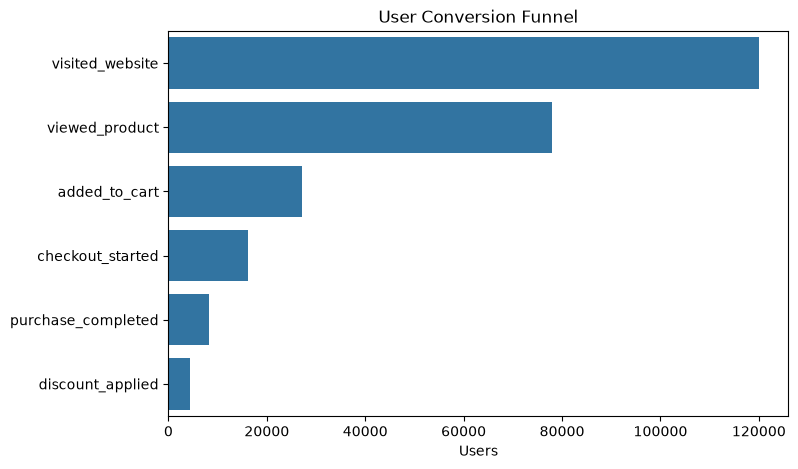

In [13]:
plt.figure(figsize=(8,5))

sns.barplot( data=funnel, x='users', y='stage')
plt.title('User Conversion Funnel')
plt.xlabel('Users')
plt.ylabel('')

plt.show()

In [ ]:
6. Анализ каналов привлечения

Бизнес-вопрос:

Какие каналы приводят самых ценных пользователей?

In [14]:
df['channel'].value_counts()

channel
Paid Ads    53891
Organic     35946
Social      18071
Email       12092
Name: count, dtype: int64

In [15]:
df.groupby('channel')['purchase_completed'].value_counts()

channel   purchase_completed
Email     No                    11208
          Yes                     884
Organic   No                    33498
          Yes                    2448
Paid Ads  No                    50272
          Yes                    3619
Social    No                    16841
          Yes                    1230
Name: count, dtype: int64

In [16]:
channel_conversion=(df.groupby('channel')['purchase_completed'].apply(lambda x:(x=='Yes').mean()*100).reset_index()) 
channel_conversion.columns = ['channel', 'conversion_rate'] 
channel_conversion

,channel,conversion_rate
0,Email,7.310619
1,Organic,6.810215
2,Paid Ads,6.715407
3,Social,6.806486


In [17]:
channel_users=(df.groupby('channel').size().reset_index(name='users'))
channel_analysis=channel_conversion.merge(channel_users, on='channel')
channel_analysis

,channel,conversion_rate,users
0,Email,7.310619,12092
1,Organic,6.810215,35946
2,Paid Ads,6.715407,53891
3,Social,6.806486,18071


In [18]:
revenue_by_channel=(df.groupby('channel')['revenue'].sum().sort_values(ascending=False))
revenue_by_channel

channel
Paid Ads    7536147.080
Organic     5090708.447
Social      2578443.312
Email       1811300.315
Name: revenue, dtype: float64

In [19]:
avg_order_channel=(df[df['purchase_completed']=='Yes'].groupby('channel')['order_value'].mean().sort_values(ascending=False))
avg_order_channel

channel
Social      2214.937756
Paid Ads    2201.156060
Organic     2200.618587
Email       2172.362466
Name: order_value, dtype: float64

In [20]:
channel_revenue=(
    df[df['purchase_completed']=='Yes'].groupby('channel').agg(
        purchases=('purchase_completed','count'),
        revenue=('revenue', 'sum'),
        avg_order=('order_value', 'mean'))
    .sort_values('revenue', ascending=False))
channel_revenue
                                                                            

,purchases,revenue,avg_order
channel,,,
Paid Ads,3619,7536147.080,2201.156060
Organic,2448,5090708.447,2200.618587
Social,1230,2578443.312,2214.937756
Email,884,1811300.315,2172.362466


In [21]:
revenue_per_user = (df.groupby('channel').agg(
        users=('user_id','count'),
        revenue=('revenue','sum')))

revenue_per_user['revenue_per_user'] = (revenue_per_user['revenue'] /revenue_per_user['users'])

revenue_per_user

,users,revenue,revenue_per_user
channel,,,
Email,12092,1811300.315,149.793278
Organic,35946,5090708.447,141.620999
Paid Ads,53891,7536147.080,139.840550
Social,18071,2578443.312,142.684041


In [22]:
channel_share=(df[df['purchase_completed']=='Yes'].groupby('channel')['revenue'].sum())
channel_share=(channel_share/channel_share.sum()*100)
channel_share.sort_values(ascending=False)

channel
Paid Ads    44.287034
Organic     29.916133
Social      15.152518
Email       10.644314
Name: revenue, dtype: float64

In [ ]:
Вывод

Paid Ads приводит больше всего покупателей.

Email показывает более высокую эффективность
по выручке на одного пользователя.

In [ ]:
7. Анализ эффективности каналов

Сравниваем каналы по:

- количеству пользователей
- выручке
- выручке на пользователя

In [23]:
channel_efficiency = (df.groupby('channel')
    .agg(
        users=('user_id','nunique'),
        revenue=('revenue','sum')))

channel_efficiency['revenue_per_user'] = (
    channel_efficiency['revenue'] / channel_efficiency['users'])

channel_efficiency

,users,revenue,revenue_per_user
channel,,,
Email,12019,1811300.315,150.703080
Organic,35225,5090708.447,144.519757
Paid Ads,52346,7536147.080,143.967965
Social,17897,2578443.312,144.071258


In [ ]:
8. Сегментация пользователей

Сравниваем поведение:

- новых пользователей
- возвращающихся пользователей

In [24]:
df['user_type'].value_counts()

user_type
New          77969
Returning    42031
Name: count, dtype: int64

In [25]:
df.groupby('user_type')['purchase_completed'].value_counts()

user_type  purchase_completed
New        No                    72571
           Yes                    5398
Returning  No                    39248
           Yes                    2783
Name: count, dtype: int64

In [26]:
user_conversion=(df.groupby('user_type')['purchase_completed'].apply(lambda x: (x=='Yes').mean()*100).reset_index())
user_conversion.columns=['user_type', 'conversion_rate']
user_conversion

,user_type,conversion_rate
0,New,6.923264
1,Returning,6.621303


In [65]:
user_revenue=(df[df['purchase_completed']=='Yes'].groupby('user_type')
     .agg(
        purchases=('purchase_completed', 'count'),
        revenue=('revenue', 'sum'),
        avg_order=('order_value', 'mean')))
user_revenue.style.format({'revenue': '{:,.0f}'})

,purchases,revenue,avg_order
user_type,,,
New,5398,"11,225,802",2200.401206
Returning,2783,"5,790,797",2199.092429


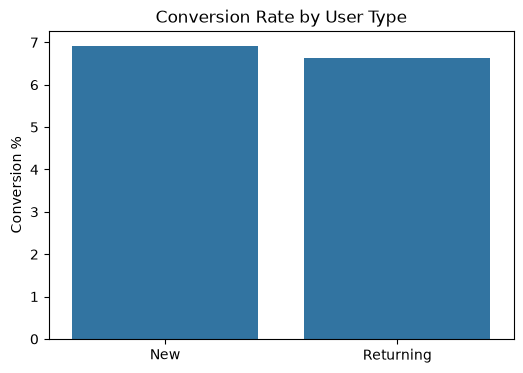

In [28]:
plt.figure(figsize=(6,4))
sns.barplot(data=user_conversion, x='user_type', y='conversion_rate')
plt.title('Conversion Rate by User Type')
plt.ylabel('Conversion %')
plt.xlabel('')
plt.show()

In [ ]:
9. Анализ влияния скидок

Проверяем:

- увеличивают ли скидки конверсию
- влияют ли они на средний чек
- как меняется выручка

In [29]:
discount_purchase_share = (
    df[df['purchase_completed']=='Yes']['discount_applied'].value_counts(normalize=True)*100)

discount_purchase_share

discount_applied
Yes    54.54101
No     45.45899
Name: proportion, dtype: float64

In [30]:
orders = df[df['purchase_completed']=='Yes']

orders['discount_applied'].value_counts()

discount_applied
Yes    4462
No     3719
Name: count, dtype: int64

In [31]:
df.groupby('discount_applied')['user_id'].nunique()

discount_applied
No     108459
Yes      4447
Name: user_id, dtype: int64

In [32]:
discount_orders = (
    orders.groupby('discount_applied')
    .agg(
        orders=('user_id','count'),
        revenue=('revenue','sum'),
        avg_order=('order_value','mean')))

discount_orders

,orders,revenue,avg_order
discount_applied,,,
No,3719,8185432.080,2200.976628
Yes,4462,8831167.074,2199.105303


In [ ]:
10. Анализ поведения по устройствам

Проверяем различия между:

- мобильными пользователями
- пользователями компьютеров

Цель:

Найти возможные проблемы пользовательского опыта.

In [33]:
df['device'].value_counts()

device
Mobile     84006
Desktop    35994
Name: count, dtype: int64

In [34]:
device_conversion = (df.groupby('device')['purchase_completed']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .reset_index())

device_conversion.columns = ['device','conversion_rate']

device_conversion

,device,conversion_rate
0,Desktop,6.912263
1,Mobile,6.776897


In [66]:
device_revenue = (df[df['purchase_completed']=='Yes']
    .groupby('device')
    .agg(
        purchases=('purchase_completed','count'),
        revenue=('revenue','sum'),
        avg_order=('order_value','mean')))

device_revenue.style.format({'revenue': '{:,.0f}'})

,purchases,revenue,avg_order
device,,,
Desktop,2488,"5,172,967",2196.918006
Mobile,5693,"11,843,632",2201.283671


In [36]:
device_funnel = (df.groupby('device')
    [['visited_website',
      'viewed_product',
      'added_to_cart',
      'checkout_started',
      'purchase_completed']]
    .apply(lambda x: (x == 'Yes').mean()*100))

device_funnel

,visited_website,viewed_product,added_to_cart,checkout_started,purchase_completed
device,,,,,
Desktop,100.0,64.935823,22.614880,13.593932,6.912263
Mobile,100.0,64.872747,22.636478,13.500226,6.776897


In [67]:
summary = pd.DataFrame({
    'Metric': [
        'Total Users',
        'Purchase Conversion',
        'Total Revenue',
        'Average Order Value'],
    'Value': [
        df['user_id'].nunique(),
        (df['purchase_completed']=='Yes').mean()*100,
        df['revenue'].sum(),
        df[df['purchase_completed']=='Yes']['order_value'].mean()]})

summary.style.format({'Value': '{:,.0f}'})

,Metric,Value
0,Total Users,"112,352"
1,Purchase Conversion,7
2,Total Revenue,"17,016,599"
3,Average Order Value,"2,200"


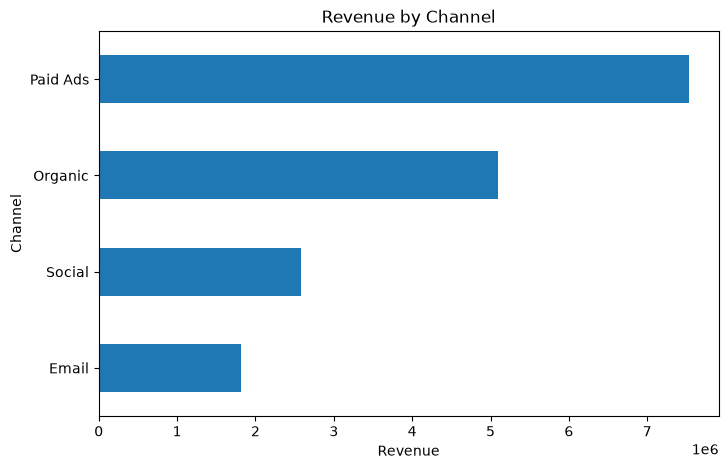

In [38]:
plt.figure(figsize=(8,5))

revenue_by_channel = (df[df['purchase_completed']=='Yes']
    .groupby('channel')['revenue']
    .sum()
    .sort_values())

revenue_by_channel.plot(kind='barh')

plt.title('Revenue by Channel')
plt.xlabel('Revenue')
plt.ylabel('Channel')

plt.show()

In [39]:
purchase_rate = (df['purchase_completed'].eq('Yes').mean()*100)

print(f"Purchase conversion rate: {purchase_rate:.2f}%")

Purchase conversion rate: 6.82%


In [40]:
user_purchase = (df.groupby('user_id')['purchase_completed'].apply(lambda x: (x=='Yes').sum()))

user_purchase.head()

user_id
100005    0
100013    1
100015    0
100025    0
100027    1
Name: purchase_completed, dtype: int64

In [41]:
user_segments = pd.cut(
    user_purchase,
    bins=[-1,0,1,5,100],
    labels=[
        'No purchase',
        'One-time buyer',
        'Active buyer',
        'High value buyer'])

user_segments.value_counts()

purchase_completed
No purchase         104213
One-time buyer        8097
Active buyer            42
High value buyer         0
Name: count, dtype: int64

In [68]:
kpis = {
    "Users": df['user_id'].nunique(),
    "Sessions": df['session_id'].nunique(),
    "Revenue": df['revenue'].sum(),
    "Purchases": (df['purchase_completed']=='Yes').sum(),
    "Conversion %": round((df['purchase_completed']=='Yes').mean()*100, 2),
    "Avg Order Value": round(df[df['purchase_completed']=='Yes']['order_value'].mean(), 2)}

pd.DataFrame(kpis.items(),columns=['Metric','Value']).style.format({'Value': '{:,.0f}'})

,Metric,Value
0,Users,"112,352"
1,Sessions,"120,000"
2,Revenue,"17,016,599"
3,Purchases,"8,181"
4,Conversion %,7
5,Avg Order Value,"2,200"


In [ ]:
11. Анализ удержания пользователей (Retention)

Изучаем:

Возвращаются ли пользователи после первого взаимодействия с продуктом.

Цель:

Понять качество удержания пользователей.

In [43]:
df['date'] = pd.to_datetime(df['date'])

In [44]:
df['date'].min(), df['date'].max()

(Timestamp('2025-07-01 00:00:00'), Timestamp('2025-12-27 00:00:00'))

In [45]:
user_first_date = (df.groupby('user_id')['date']
    .min()
    .reset_index())

user_first_date.columns = ['user_id','first_date']

user_first_date.head()

,user_id,first_date
0,100005,2025-07-14
1,100013,2025-12-25
2,100015,2025-07-16
3,100025,2025-08-12
4,100027,2025-11-23


In [46]:
df = df.merge(user_first_date, on='user_id')

In [47]:
df['cohort_month'] = (df['first_date'].dt.to_period('M'))

In [57]:
df['activity_month'] = (df['date'].dt.to_period('M'))

df['cohort_index'] = (df['activity_month']- df['cohort_month']).apply(lambda x :x.n)


In [49]:
cohort_data = (df.groupby(['cohort_month','cohort_index'])['user_id']
    .nunique()
    .reset_index())

cohort_table = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='user_id')

cohort_table

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2025-07,20529.0,453.0,444.0,466.0,457.0,425.0
2025-08,19781.0,423.0,475.0,434.0,376.0,NaN
2025-09,19080.0,479.0,403.0,377.0,NaN,NaN
2025-10,18977.0,410.0,377.0,NaN,NaN,NaN
2025-11,17996.0,350.0,NaN,NaN,NaN,NaN
2025-12,15989.0,NaN,NaN,NaN,NaN,NaN


In [70]:
retention = cohort_table.div(cohort_table.iloc[:,0],axis=0)*100

retention.round(1)

cohort_index,0,1,2,3,4,5
cohort_month,,,,,,
2025-07,100.0,2.2,2.2,2.3,2.2,2.1
2025-08,100.0,2.1,2.4,2.2,1.9,NaN
2025-09,100.0,2.5,2.1,2.0,NaN,NaN
2025-10,100.0,2.2,2.0,NaN,NaN,NaN
2025-11,100.0,1.9,NaN,NaN,NaN,NaN
2025-12,100.0,NaN,NaN,NaN,NaN,NaN


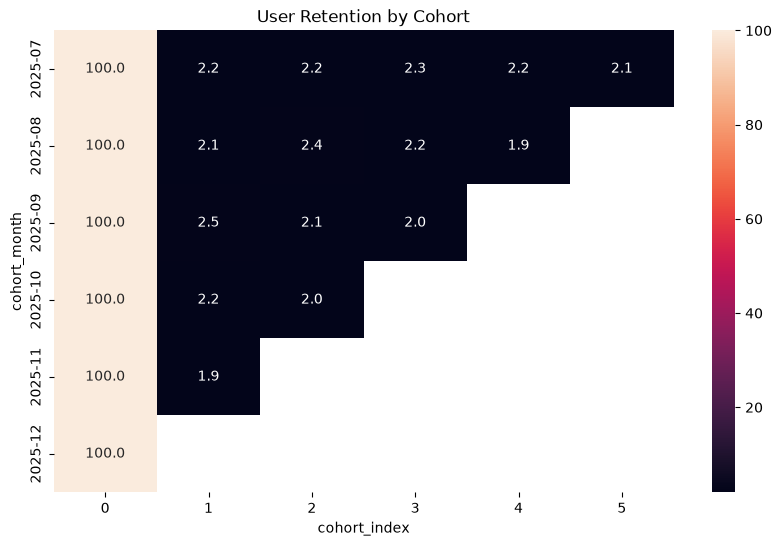

In [58]:
plt.figure(figsize=(10,6))

sns.heatmap(retention,annot=True,fmt='.1f', mask=retention.isna())

plt.title('User Retention by Cohort')

plt.show()

In [ ]:
Выводы по Retention анализу

Когортный анализ показал низкий уровень удержания пользователей.

После первого месяца активность пользователей снижается:
примерно 2–2.5% пользователей возвращаются в следующие периоды.

Это может указывать на:

- слабое повторное вовлечение пользователей
- отсутствие причин возвращаться в продукт
- необходимость улучшения retention-механик

Важно: последние когорты имеют NaN, так как пользователи из этих месяцев ещё не имели достаточно времени для повторной активности.

In [ ]:
12. 'Top Users' анализ

Выявляем самых ценных пользователей

In [52]:
top_users = (df[df['purchase_completed']=='Yes']
    .groupby('user_id')
    .agg(
        purchases=('purchase_completed','count'),
        revenue=('revenue','sum'))
    .sort_values('revenue',ascending=False).head(10))

top_users

,purchases,revenue
user_id,,
607314,2,6946.802
301157,2,6124.572
561849,2,5843.214
476993,2,5335.230
124300,2,5291.334
885290,2,5278.599
893981,2,5201.377
216603,2,5157.741
635900,2,5133.946


In [53]:
top10_share = (top_users['revenue'].sum()/df['revenue'].sum()*100)

print(f"Top 10 users generate {top10_share:.2f}% of revenue")

Top 10 users generate 0.33% of revenue


In [ ]:
13. Факторы, влияющие на конверсию

Определяем, какие признаки связаны с совершением покупки.

Анализируем:

- канал привлечения
- устройство
- тип пользователя
- регион

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

model_df = df.copy()

for col in ['channel','device','user_type','region']: model_df[col] = LabelEncoder().fit_transform(model_df[col])

X = model_df[['channel','device','user_type','region']]

y = (model_df['purchase_completed']== 'Yes')

model = DecisionTreeClassifier(max_depth=3,random_state=42)

model.fit(X,y)

pd.DataFrame({'feature':X.columns,'importance':model.feature_importances_})

,feature,importance
0,channel,0.188197
1,device,0.197572
2,user_type,0.423987
3,region,0.190244


In [ ]:
14. Финальные выводы

Основная потеря пользователей происходит между просмотром товара и добавлением в корзину.

    Рекомендация:

Улучшить карточки товаров:
- описание
- фотографии
- доверие к продукту

 Оптимизация рекламы

Email показывает высокую ценность пользователей, но требует оптимизации количества трафика

Paid Ads приводит большой объём пользователей, но требует оптимизации качества трафика.

 Работа со скидками

Провести A/B тестирование скидочных механик, чтобы найти баланс между конверсией и прибылью.